## Practice Activity 7-1: Association Rules Mining

In the reading you analyzed transactions from a bakery. In this activity you will carry out a very similar analysis for purchases from a grocery store.

In [1]:
import pandas as pd

from plotnine import *

from mlxtend.frequent_patterns import apriori, association_rules

# to stop an annoying warning
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

## Groceries data set

- One month (30 days) of real point-of-sale transactions from a grocery store.
- 9,835 transactions (baskets).
- 169 product categories, such as whole milk, yogurt, bottled beer, etc.
- Source: the data set `Groceries` in the R package `arules`, provided by Hahsler, Hornik, and Reutterer. The copy we use is a plain-text version hosted on GitHub.


The file format is different from the bakery file. The bakery file had one row per item bought. This file has **one line per transaction**, and each line is a comma-separated list of the items in that basket. Different baskets have different numbers of items.

The next cell reads each line into a single text column. (Normal CSV reading expects every row to have the same number of columns, so we read each line as one string, using a separator `"|"` that never occurs in the file.)

In [2]:
import csv

raw = pd.read_csv(
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv",
    header=None,             # the file has no header row: line 1 is already a transaction
    names=["basket"],        # name the one column we create
    sep="|",                 # "|" never appears in this file, so each whole line lands in one column
    quoting=csv.QUOTE_NONE,  # treat any quote characters as ordinary text
)

In [3]:
raw

,basket
0,"citrus fruit,semi-finished bread,margarine,rea..."
1,"tropical fruit,yogurt,coffee"
2,whole milk
3,"pip fruit,yogurt,cream cheese ,meat spreads"
4,"other vegetables,whole milk,condensed milk,lon..."
...,...
9830,"sausage,chicken,beef,hamburger meat,citrus fru..."
9831,cooking chocolate
9832,"chicken,citrus fruit,other vegetables,butter,y..."
9833,"semi-finished bread,bottled water,soda,bottled..."


We'll start with the data in long format like in the reading.

- Make a column `basket_id` from the row number (`raw.index`).
- Split the text in `raw["basket"]` at the commas, using `.str.split(",")`. This produces a *list* of items in each row.
- Use `.explode(...)` on the column of lists to get one row per item.
- Keep only `basket_id` and `item`, and use `.reset_index(drop=True)`.
- Trim spaces

In [4]:
long = (
    raw
    .assign(basket_id=raw.index)                    # use the row number as the basket ID
    .assign(item=raw["basket"].str.split(","))      # "milk,bread" becomes ["milk", "bread"]
    .explode("item")                                # one row per (basket, item)
    [["basket_id", "item"]]                         # keep only the two columns we need
    .reset_index(drop=True)                         # renumber the rows 0, 1, 2, ...
)

long["item"] = long["item"].str.strip()             # remove stray leading/trailing spaces

long

,basket_id,item
0,0,citrus fruit
1,0,semi-finished bread
2,0,margarine
3,0,ready soups
4,1,tropical fruit
...,...,...
43362,9834,chicken
43363,9834,tropical fruit
43364,9834,other vegetables
43365,9834,vinegar


1. Build the transaction-by-item table `basket`. There should be one row per basket, one column per item, with `True` if the item is in the basket and `False` otherwise.

In [ ]:
long['indicator'] = True

basket = long.pivot(index="basket_id", columns="item", values="indicator").fillna(False)
basket

2.  Compute the size (number of items) of each basket and store it in `basket_sizes`.

In [6]:
basket_sizes = basket.sum(axis=1)
basket_sizes

trans_id
0        4
1        3
2        1
3        4
4        4
        ..
9830    17
9831     1
9832    10
9833     4
9834     5
Length: 9835, dtype: int64

3. Summarize the distribution of the number of items.

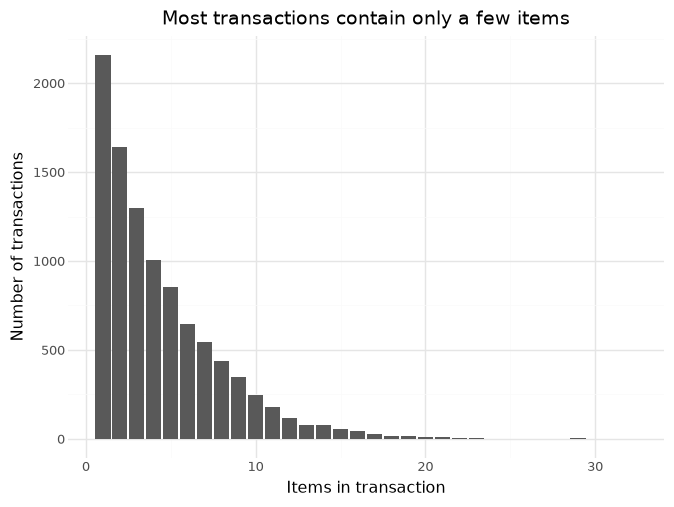

In [7]:
sizes_df = basket_sizes.value_counts().sort_index().rename_axis("n_items").reset_index(name="n_transactions")

(
    ggplot(sizes_df, aes(x="n_items", y="n_transactions"))
    + geom_col()
    + labs(x="Items in transaction", y="Number of transactions", title="Most transactions contain only a few items")
    + theme_minimal()
)

4. Compute the support of every item, sorted from largest to smallest, and store it in `item_support`. Then make a horizontal bar chart of the 15 most popular items.

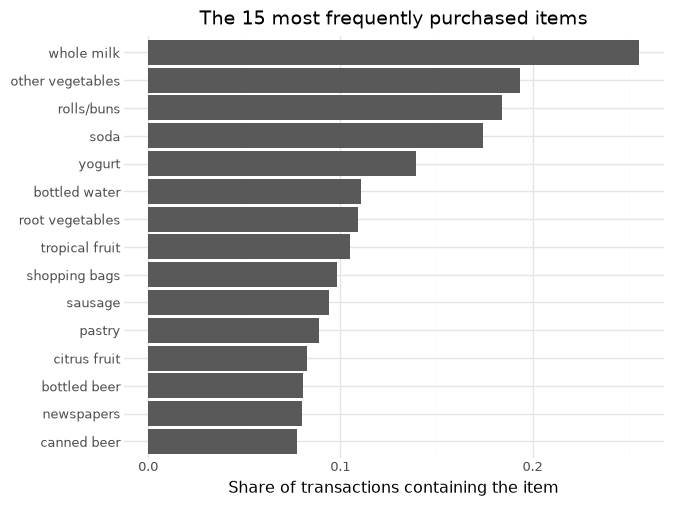

In [8]:
item_support = basket.mean().sort_values(ascending=False)

top15 = item_support.head(15).rename("support").reset_index()

top15["item"] = pd.Categorical(top15["item"], categories=top15["item"].tolist()[::-1], ordered=True)

(
    ggplot(top15, aes(x="item", y="support"))
    + geom_col()
    + coord_flip()
    + labs(x="", y="Share of transactions containing the item", title="The 15 most frequently purchased items")
    + theme_minimal()
)

5. Consider the basket sizes and the item supports. Which item is most popular, and in what percentage of baskets does it appear? Which items are most common? What does this suggest about the "popular items co-occur just by chance" problem discussed in the reading?

In [9]:
top15

,item,support
0,whole milk,0.255516
1,other vegetables,0.193493
2,rolls/buns,0.183935
3,soda,0.174377
4,yogurt,0.139502
5,bottled water,0.110524
6,root vegetables,0.108998
7,tropical fruit,0.104931
8,shopping bags,0.098526
9,sausage,0.093950


6. Consider the rule **{yogurt} → {whole milk}**. Compute and interpret the confidence of this rule.


In [10]:
yogurt_support = basket["yogurt"].mean()

yogurt_milk_support = (basket["yogurt"] & basket["whole milk"]).mean()

yogurt_to_milk_confidence = yogurt_milk_support / yogurt_support
print("Confidence:", yogurt_to_milk_confidence)

Confidence: 0.40160349854227406


7. Compute and interpret the **lift** of {yogurt} → {whole milk}.

In [11]:
whole_milk_support = basket["whole milk"].mean()

yogurt_to_milk_lift = yogurt_to_milk_confidence / whole_milk_support
print("Lift:", yogurt_to_milk_lift)

Lift: 1.5717351405345266


8. Now compute and interpret the confidence and lift for the rule {whole milk} → {yogurt}.

In [12]:
milk_to_yogurt_confidence = yogurt_milk_support / whole_milk_support
print("Confidence:", milk_to_yogurt_confidence)

milk_to_yogurt_lift = milk_to_yogurt_confidence / yogurt_support
print("Lift:", milk_to_yogurt_lift)

Confidence: 0.21925984878631116
Lift: 1.5717351405345263


9. Write two functions.

- `support(items, onehot)`: returns the share of baskets that contain **all** of the items in the list `items`.
- `rule_metrics(antecedent, consequent, onehot)`: returns a Pandas Series with the `support`, `confidence`, and `lift` of the rule `antecedent -> consequent`. Both `antecedent` and `consequent` are *lists* of items.

Test the functions on `["yogurt"]` → `["whole milk"]`. The values should match the ones you computed earlier.

In [13]:
def support(items, onehot):
  return onehot[items].all(axis=1).mean()

support(['yogurt'], basket)

np.float64(0.13950177935943062)

In [28]:
def rule_metrics(antecedent, consequenct, onehot):
  antecedent_support = support(antecedent, onehot)
  consequent_support = support(consequenct, onehot)
  antecedent_consequent_support = support(antecedent + consequenct, onehot)
  confidence = antecedent_consequent_support / antecedent_support
  lift = confidence / consequent_support
  return pd.Series({'support': antecedent_support, 'confidence': confidence, 'lift': lift})

rule_metrics(['yogurt'], ['whole milk'], basket)

support       0.139502
confidence    0.401603
lift          1.571735
dtype: float64

10. Whole milk is in about a quarter of all baskets. Consider the rules `{X} → {whole milk}` for the five antecedents `X` in the next cell. Before running anything, predict: for which of these will the lift be **above 1**? For which might the confidence look decent but the lift be **close to or below 1**? Just think about this before proceeding.

In [15]:
antecedents = pd.Series(["yogurt", "rolls/buns", "bottled water", "soda", "other vegetables"])

11. Compute the support, confidence, and lift of `{X} → {whole milk}` for each of the five antecedents above, and display the results sorted by lift (largest first). Compare to your predictions. Hint: Use `apply` with `lambda` on the Series of antecedents.


In [16]:
antecedents.apply(lambda x: rule_metrics([x], ['whole milk'], basket)).sort_values('lift', ascending=False)

,support,confidence,lift
0,0.139502,0.401603,1.571735
4,0.193493,0.386758,1.513634
2,0.110524,0.310948,1.216940
1,0.183935,0.307905,1.205032
3,0.174377,0.229738,0.899112


12. Run `apriori` on `basket` with `min_support=0.01` and store the result in `frequent_itemsets`. Then add a column `n_items` giving the number of items in each itemset.

In [17]:
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)
frequent_itemsets['n_items'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

13. Generate the rules with `make_rules`, keeping rules with confidence of at least 0.20. Store them in `rules` and print how many there are.

In [18]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.20)
print(f"Number of rules: {len(rules)}")

Number of rules: 234


14. Make the rules easier to read. Create a copy `rules_display` of `rules` and add three columns:

- `antecedent`: the antecedent items as text, e.g. `"tropical fruit, yogurt"`
- `consequent`: the consequent items as text
- `transactions`: the number of baskets that contain the whole rule (support times the number of baskets, rounded to an integer)

Then display the columns `antecedent`, `consequent`, `support`, `confidence`, `lift`, `transactions` for the first 8 rules.

In [19]:
rules_display = rules.copy()
rules_display['antecedent'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_display['consequent'] = rules_display['consequents'].apply(lambda x: ', '.join(list(x)))
rules_display['transactions'] = round(rules_display['support'] * len(basket)).astype(int)
rules_display[['antecedent', 'consequent', 'support', 'confidence', 'lift', 'transactions']].head(8)

,antecedent,consequent,support,confidence,lift,transactions
0,beef,other vegetables,0.019725,0.375969,1.943066,194
1,beef,rolls/buns,0.013625,0.259690,1.411858,134
2,beef,root vegetables,0.017387,0.331395,3.040367,171
3,beef,whole milk,0.021251,0.405039,1.585180,209
4,beef,yogurt,0.011693,0.222868,1.597601,115
5,berries,other vegetables,0.010269,0.308869,1.596280,101
6,berries,whole milk,0.011795,0.354740,1.388328,116
7,berries,yogurt,0.010574,0.318043,2.279848,104


15. Show the 10 rules with the highest **confidence**. What do the highest-confidence rules have in common? Why is confidence alone a poor guide here?

In [20]:
rules_display.sort_values('confidence', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent,consequent,transactions
157,"frozenset({citrus fruit, root vegetables})",frozenset({other vegetables}),0.017692,0.193493,0.010371,0.586207,3.029608,1.0,0.006948,1.949059,0.681990,0.051646,0.486932,0.319903,"citrus fruit, root vegetables",other vegetables,102
185,"frozenset({tropical fruit, root vegetables})",frozenset({other vegetables}),0.021047,0.193493,0.012303,0.584541,3.020999,1.0,0.008231,1.941244,0.683367,0.060835,0.484867,0.324062,"tropical fruit, root vegetables",other vegetables,121
164,"frozenset({yogurt, curd})",frozenset({whole milk}),0.017285,0.255516,0.010066,0.582353,2.279125,1.0,0.005649,1.782567,0.571107,0.038313,0.439011,0.310874,"yogurt, curd",whole milk,99
153,"frozenset({other vegetables, butter})",frozenset({whole milk}),0.020031,0.255516,0.011490,0.573604,2.244885,1.0,0.006371,1.745992,0.565878,0.043512,0.427260,0.309285,"other vegetables, butter",whole milk,113
222,"frozenset({tropical fruit, root vegetables})",frozenset({whole milk}),0.021047,0.255516,0.011998,0.570048,2.230969,1.0,0.006620,1.731553,0.563627,0.045350,0.422484,0.308502,"tropical fruit, root vegetables",whole milk,118
226,"frozenset({yogurt, root vegetables})",frozenset({whole milk}),0.025826,0.255516,0.014540,0.562992,2.203354,1.0,0.007941,1.703594,0.560625,0.054497,0.413006,0.309948,"yogurt, root vegetables",whole milk,143
165,"frozenset({other vegetables, domestic eggs})",frozenset({whole milk}),0.022267,0.255516,0.012303,0.552511,2.162336,1.0,0.006613,1.663694,0.549779,0.046342,0.398928,0.300331,"other vegetables, domestic eggs",whole milk,121
233,"frozenset({yogurt, whipped/sour cream})",frozenset({whole milk}),0.020742,0.255516,0.010880,0.524510,2.052747,1.0,0.005580,1.565719,0.523711,0.040996,0.361316,0.283544,"yogurt, whipped/sour cream",whole milk,107
215,"frozenset({rolls/buns, root vegetables})",frozenset({whole milk}),0.024301,0.255516,0.012710,0.523013,2.046888,1.0,0.006500,1.560804,0.524192,0.047583,0.359305,0.286377,"rolls/buns, root vegetables",whole milk,125
171,"frozenset({other vegetables, pip fruit})",frozenset({whole milk}),0.026131,0.255516,0.013523,0.517510,2.025351,1.0,0.006846,1.543003,0.519843,0.050436,0.351913,0.285217,"other vegetables, pip fruit",whole milk,133


16. Show the 10 rules with the highest **lift**. Compare this list with the highest-confidence list. What kinds of products appear now? Look at the `support` and `transactions` columns: how much evidence is each of these rules based on?

In [21]:
rules_display.sort_values('lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent,consequent,transactions
156,"frozenset({citrus fruit, other vegetables})",frozenset({root vegetables}),0.028876,0.108998,0.010371,0.359155,3.295045,1.0,0.007224,1.390354,0.717225,0.081340,0.280759,0.227152,"citrus fruit, other vegetables",root vegetables,102
207,"frozenset({other vegetables, yogurt})",frozenset({whipped/sour cream}),0.043416,0.071683,0.010168,0.234192,3.267062,1.0,0.007056,1.212206,0.725409,0.096899,0.175058,0.188018,"other vegetables, yogurt",whipped/sour cream,100
184,"frozenset({tropical fruit, other vegetables})",frozenset({root vegetables}),0.035892,0.108998,0.012303,0.342776,3.144780,1.0,0.008391,1.355705,0.707403,0.092791,0.262376,0.227825,"tropical fruit, other vegetables",root vegetables,121
2,frozenset({beef}),frozenset({root vegetables}),0.052466,0.108998,0.017387,0.331395,3.040367,1.0,0.011668,1.332628,0.708251,0.120677,0.249603,0.245455,beef,root vegetables,171
157,"frozenset({citrus fruit, root vegetables})",frozenset({other vegetables}),0.017692,0.193493,0.010371,0.586207,3.029608,1.0,0.006948,1.949059,0.681990,0.051646,0.486932,0.319903,"citrus fruit, root vegetables",other vegetables,102
185,"frozenset({tropical fruit, root vegetables})",frozenset({other vegetables}),0.021047,0.193493,0.012303,0.584541,3.020999,1.0,0.008231,1.941244,0.683367,0.060835,0.484867,0.324062,"tropical fruit, root vegetables",other vegetables,121
190,frozenset({root vegetables}),"frozenset({other vegetables, whole milk})",0.108998,0.074835,0.023183,0.212687,2.842082,1.0,0.015026,1.175091,0.727435,0.144304,0.149002,0.261235,root vegetables,"other vegetables, whole milk",228
187,"frozenset({other vegetables, whole milk})",frozenset({root vegetables}),0.074835,0.108998,0.023183,0.309783,2.842082,1.0,0.015026,1.290900,0.700572,0.144304,0.225347,0.261235,"other vegetables, whole milk",root vegetables,228
155,frozenset({butter}),"frozenset({other vegetables, whole milk})",0.055414,0.074835,0.011490,0.207339,2.770630,1.0,0.007343,1.167164,0.676562,0.096747,0.143223,0.180436,butter,"other vegetables, whole milk",113
163,"frozenset({whole milk, curd})",frozenset({yogurt}),0.026131,0.139502,0.010066,0.385214,2.761356,1.0,0.006421,1.399671,0.654974,0.064706,0.285546,0.228686,"whole milk, curd",yogurt,99


17. Create `interesting_rules`: the rules with **confidence of at least 0.30 and lift of at least 1.5**, sorted by lift (largest first).


In [22]:
interesting_rules = rules_display[(rules_display['confidence'] >= 0.30) & (rules_display['lift'] >= 1.5)].sort_values('lift', ascending=False)
interesting_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent,consequent,transactions
156,"frozenset({citrus fruit, other vegetables})",frozenset({root vegetables}),0.028876,0.108998,0.010371,0.359155,3.295045,1.0,0.007224,1.390354,0.717225,0.081340,0.280759,0.227152,"citrus fruit, other vegetables",root vegetables,102
184,"frozenset({tropical fruit, other vegetables})",frozenset({root vegetables}),0.035892,0.108998,0.012303,0.342776,3.144780,1.0,0.008391,1.355705,0.707403,0.092791,0.262376,0.227825,"tropical fruit, other vegetables",root vegetables,121
2,frozenset({beef}),frozenset({root vegetables}),0.052466,0.108998,0.017387,0.331395,3.040367,1.0,0.011668,1.332628,0.708251,0.120677,0.249603,0.245455,beef,root vegetables,171
157,"frozenset({citrus fruit, root vegetables})",frozenset({other vegetables}),0.017692,0.193493,0.010371,0.586207,3.029608,1.0,0.006948,1.949059,0.681990,0.051646,0.486932,0.319903,"citrus fruit, root vegetables",other vegetables,102
185,"frozenset({tropical fruit, root vegetables})",frozenset({other vegetables}),0.021047,0.193493,0.012303,0.584541,3.020999,1.0,0.008231,1.941244,0.683367,0.060835,0.484867,0.324062,"tropical fruit, root vegetables",other vegetables,121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,frozenset({onions}),frozenset({whole milk}),0.031012,0.255516,0.012100,0.390164,1.526965,1.0,0.004176,1.220794,0.356151,0.044090,0.180861,0.218759,onions,whole milk,119
72,frozenset({hygiene articles}),frozenset({whole milk}),0.032944,0.255516,0.012811,0.388889,1.521975,1.0,0.004394,1.218247,0.354642,0.046477,0.179148,0.219514,hygiene articles,whole milk,126
17,frozenset({brown bread}),frozenset({whole milk}),0.064870,0.255516,0.025216,0.388715,1.521293,1.0,0.008641,1.217899,0.366435,0.085429,0.178914,0.243701,brown bread,whole milk,248
105,frozenset({other vegetables}),frozenset({whole milk}),0.193493,0.255516,0.074835,0.386758,1.513634,1.0,0.025394,1.214013,0.420750,0.200000,0.176286,0.339817,other vegetables,whole milk,736


18. Choose **one** rule from the table and interpret its **support**, **confidence**, and **lift** with numbers, as you did for {yogurt} → {whole milk}.

{onions} --> {whole milk}:

support = 0.031: The combination of onions and whole milk is about 3.1% of all combos.

confidence = 0.3902: Those who buy onions also bought whole milk 39.02% of the time.

lift = 1.53: Whole milk is about 1.53 times more common in baskets with onions than those without it.

19. The manager wants to **increase sales of yogurt**. Which products should the store link to yogurt (shelf placement, a joint promotion, a recommendation)?

In [23]:
interesting_rules[interesting_rules['consequent'].str.contains('yogurt')].sort_values('lift', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent,consequent,transactions
163,"frozenset({whole milk, curd})",frozenset({yogurt}),0.026131,0.139502,0.010066,0.385214,2.761356,1.0,0.006421,1.399671,0.654974,0.064706,0.285546,0.228686,"whole milk, curd",yogurt,99
229,"frozenset({tropical fruit, whole milk})",frozenset({yogurt}),0.042298,0.139502,0.015150,0.358173,2.567516,1.0,0.009249,1.340701,0.637483,0.090909,0.254122,0.233387,"tropical fruit, whole milk",yogurt,149
208,"frozenset({other vegetables, whipped/sour cream})",frozenset({yogurt}),0.028876,0.139502,0.010168,0.352113,2.524073,1.0,0.006139,1.328160,0.621769,0.064267,0.247079,0.212499,"other vegetables, whipped/sour cream",yogurt,100
201,"frozenset({tropical fruit, other vegetables})",frozenset({yogurt}),0.035892,0.139502,0.012303,0.342776,2.457146,1.0,0.007296,1.309293,0.615101,0.075436,0.236229,0.215484,"tropical fruit, other vegetables",yogurt,121
232,"frozenset({whole milk, whipped/sour cream})",frozenset({yogurt}),0.032232,0.139502,0.010880,0.337539,2.419607,1.0,0.006383,1.298943,0.606250,0.067636,0.230143,0.207764,"whole milk, whipped/sour cream",yogurt,107
161,"frozenset({citrus fruit, whole milk})",frozenset({yogurt}),0.030503,0.139502,0.010269,0.336667,2.413350,1.0,0.006014,1.297233,0.604064,0.064290,0.229129,0.205141,"citrus fruit, whole milk",yogurt,101
47,frozenset({curd}),frozenset({yogurt}),0.053279,0.139502,0.017285,0.324427,2.325615,1.0,0.009853,1.273732,0.602085,0.098494,0.214905,0.224167,curd,yogurt,170
7,frozenset({berries}),frozenset({yogurt}),0.033249,0.139502,0.010574,0.318043,2.279848,1.0,0.005936,1.261807,0.580681,0.065204,0.207486,0.196922,berries,yogurt,104
43,frozenset({cream cheese}),frozenset({yogurt}),0.039654,0.139502,0.012405,0.312821,2.242412,1.0,0.006873,1.252218,0.576929,0.074390,0.201417,0.200871,cream cheese,yogurt,122


---
## References and attribution


- Hahsler, M., Gr&uuml;n, B., and Hornik, K. (2005). arules: A computational environment for mining association rules and frequent item sets. *Journal of Statistical Software*, 14(15). (The R package that distributes the data.)
- Data copy: GitHub repository `stedy/Machine-Learning-with-R-datasets` (`groceries.csv`), the data used in Lantz, B., *Machine Learning with R*.
- Raschka, S. (2018). MLxtend: Providing machine learning and data science utilities and extensions to Python's scientific computing stack. *Journal of Open Source Software*, 3(24), 638. <https://doi.org/10.21105/joss.00638>


**Preparation of this notebook:** drafted with the assistance of generative AI tools (ChatGPT and Claude).